## Imported Libraries

In [1]:
import os
import random
import numpy
import matplotlib.pyplot
import sklearn.model_selection
import sklearn.metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import torch
import torchvision
import collections

## Data Generator

In [2]:
# 0 or 1 in the server
gpu = "0" 

data_generator = torch.Generator()

## On GPU Balanced Accuracy Computation

In [3]:
def torch_compute_bacc(preds: torch.Tensor, labels: torch.Tensor, class_count: int):
    recall_per_class = []

    for label in range(class_count):
        true_positive = ((preds == label) & (labels == label)).sum().float()
        total_actual = (labels == label).sum().float()

        recall = true_positive / total_actual if total_actual > 0.0 else torch.tensor(0.0)
        recall_per_class.append(recall)

    return torch.stack(recall_per_class).mean().item()

## Data Preparation

In [4]:
# Glaucoma configuration
class_count = 2 # Glaucoma or not glaucoma
batch_size = 256
image_size = 224 

train_dir = "/home/jmulvihill/glaucoma-release-crop/release-crop/train"
test_dir = "/home/jmulvihill/glaucoma-release-crop/release-crop/test"
val_dir = "/home/jmulvihill/glaucoma-release-crop/release-crop/validation"

# Dataset stats saved to a npz file
# Load the saved statistical information as tensors
# See original architectures for more details
data_stats = numpy.load("Glaucoma_stats.npz")
mean = torch.tensor(data_stats['mean'], dtype=torch.float)
std = torch.tensor(data_stats['stdev'], dtype=torch.float)
label_weights = torch.tensor(data_stats['lw'], dtype=torch.float)

## Data Loading

In [5]:
# Load mean, std, and label weights that were saved earlier

""" Do not apply augmentations to testing """
test_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize(image_size),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=mean, std=std)
])

test_dataset = torchvision.datasets.ImageFolder(test_dir, transform=test_transform)

# actual data loading for test data
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, \
                                          generator=data_generator)

## EnsembleNet Implementation

In [6]:
device = torch.device("cuda:" + gpu if torch.cuda.is_available() else "cpu")

# Save the outputs from the different models to an array
alex_outputs = []
vgg_outputs = []
res_outputs = []
xcep_outputs = []

# Collect truth labels
truth_labels = []

In [7]:
# Load the AlexNet neural network class from the original file
from alexnet_class import AlexNet 

In [8]:
# Variables to the class count of the original model
# and number of channels to the last fully connected layer
alex_class_count = 10
alex_last_fc_size = 4096

# Save the output of the model class
alex = AlexNet(class_count=alex_class_count).to(device)

# Rewire last layer with appropriate outputs
alex.last = torch.nn.Linear(alex_last_fc_size, class_count)

# Load model to GPU
alex.to(device) 

# Load the AlexNet model
alex.load_state_dict(torch.load("glaucoma_alex_ft.pth"))

# Evaluate the model on the test partition
alex.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Save the outputs to an array for each model
        alex_outputs.append(alex(images))
        
        # Collect truth labels during first model evaluation
        truth_labels.append(labels)

In [9]:
# Load the VGGNet neural network class from the original file
from vggnet_class import VGG16D

In [10]:
# Variables to the class count of the original model
# and number of channels to the last fully connected layer
vgg_class_count = 10
vgg_last_fc_size = 4096

# Save the output of the model class
vgg = VGG16D(class_count=vgg_class_count).to(device)

# Rewire last layer with appropriate outputs
# classifier[6] is the index of the very last layer
vgg.classifier[6] = torch.nn.Linear(vgg_last_fc_size, class_count) 

# Load model to GPU
vgg.to(device)

# Load the VGGNet model
vgg.load_state_dict(torch.load("glaucoma_vgg_ft.pth"))

# Evaluate the model on the test partition
vgg.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Save the outputs to an array for each model
        vgg_outputs.append(vgg(images))

In [11]:
# Load the ResNet neural network class from the original file
from resnet_class import ResNet18

In [12]:
# Variables to the class count of the original model
# and number of channels to the last fully connected layer
res_class_count = 10
res_last_fc_size = 512

# Save the output of the model class
res = ResNet18(class_count=res_class_count).to(device)

# Rewire last layer with appropriate outputs
res.fc = torch.nn.Linear(res_last_fc_size, class_count) 

# Load model to GPU
res.to(device) 

# Load the ResNet model
res.load_state_dict(torch.load("glaucoma_res_ft.pth"))

# Evaluate the model on the test partition
res.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Save the outputs to an array for each model
        res_outputs.append(res(images))

In [13]:
# Load the Xception neural network class from the original file
# Xception uses an image size of 299 x 299, so had to rework the 
# original class and statistical computations to handle 224 x 224 images 
# like the other architectures
from xception_class_resized import Xception

Dataset Train Partition Stats
        Mean: tensor([0.3590, 0.2300, 0.1499])
         Std: tensor([0.2294, 0.1541, 0.1041])
Label Weights: tensor([1., 1.])


In [14]:
# Variables to the class count of the original model
# and number of channels to the last fully connected layer
xcep_class_count = 10
xcep_last_fc_size = 2048

# Save the output of the model class
xcep = Xception(class_count=xcep_class_count).to(device)

# Rewire last layer with appropriate outputs
xcep.last = torch.nn.Linear(xcep_last_fc_size, class_count) 

# Load model to GPU
xcep.to(device)

# Load the Xception model
xcep.load_state_dict(torch.load("glaucoma_xcep_ft.pth"))

# Evaluate the model on the test partition
xcep.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Save the outputs to an array for each model
        xcep_outputs.append(xcep(images))

## Process Model Outputs for Voting

In [15]:
# Concatenate batch outputs for each model
alex_pred = torch.cat(alex_outputs)
vgg_pred = torch.cat(vgg_outputs)
res_pred = torch.cat(res_outputs)
xcep_pred = torch.cat(xcep_outputs)

# Concatenate truth labels
all_truth_labels = torch.cat(truth_labels)

## Hard Majority Voting

In [16]:
def hard_maj(alex_out, vgg_out, res_out, xcep_out): 
    # Get hard predictions (class with highest score)
    alex_preds = torch.argmax(alex_out, dim=1)   # Shape: (num_samples,)
    vgg_preds = torch.argmax(vgg_out, dim=1)     # Shape: (num_samples,)
    res_preds = torch.argmax(res_out, dim=1)     # Shape: (num_samples,)
    xcep_preds = torch.argmax(xcep_out, dim=1)   # Shape: (num_samples,)
    
    # Stack predictions: shape becomes (4, num_samples)
    # Each row is one model's predictions
    # Each column is all models' predictions for one sample
    stacked_preds = torch.stack([alex_preds, vgg_preds, res_preds, xcep_preds])
    
    # Count votes for class 1 (you could also count for class 0)
    # For each sample, count how many models predicted class 1
    votes_for_class_1 = (stacked_preds == 1).sum(dim=0)  # Shape: (num_samples,)
    
    # Majority voting: if >= 2 models vote for class 1, predict 1
    # (since we have 4 models, need at least 2 votes)
    final_predictions = (votes_for_class_1 >= 2).long()
    
    return final_predictions

In [17]:
hard_voting_preds = hard_maj(alex_pred, vgg_pred, res_pred, xcep_pred)

# Compute balanced accuracy
hard_bacc = torch_compute_bacc(hard_voting_preds, all_truth_labels, class_count)
print(f'Hard majority voting balanced accuracy: {(hard_bacc * 100):.2f}%')

Hard majority voting balanced accuracy: 86.72%


## Soft Majority Voting

In [18]:
def soft_maj(alex_out, vgg_out, res_out, xcep_out):
    # Convert outputs to probabilities using softmax
    alex_probs = torch.nn.functional.softmax(alex_out, dim=1)  # Shape: (num_samples, 2)
    vgg_probs = torch.nn.functional.softmax(vgg_out, dim=1)    # Shape: (num_samples, 2)
    res_probs = torch.nn.functional.softmax(res_out, dim=1)    # Shape: (num_samples, 2)
    xcep_probs = torch.nn.functional.softmax(xcep_out, dim=1)  # Shape: (num_samples, 2)
    
    # Stack probabilities: shape becomes (4, num_samples, 2)
    # Dimension 0: models
    # Dimension 1: samples
    # Dimension 2: class probabilities
    stacked_probs = torch.stack([alex_probs, vgg_probs, res_probs, xcep_probs])
    
    # Average probabilities across models (along dimension 0)
    avg_probs = torch.mean(stacked_probs, dim=0)  # Shape: (num_samples, 2)
    
    # Take argmax of averaged probabilities
    final_predictions = torch.argmax(avg_probs, dim=1)  # Shape: (num_samples,)
    
    return final_predictions

In [19]:
soft_voting_preds = soft_maj(alex_pred, vgg_pred, res_pred, xcep_pred)

# Compute the balanced accuracy
soft_bacc = torch_compute_bacc(soft_voting_preds, all_truth_labels, class_count)
print(f'Soft majority voting balanced accuracy: {(soft_bacc * 100):.2f}%')

Soft majority voting balanced accuracy: 87.21%


## Confusion Matrix Comparison

In [20]:
# Convert predictions obtained into numpy arrays (for confusion matrix processing)
hard_maj_np = hard_voting_preds.cpu().numpy() if torch.is_tensor(hard_voting_preds) else hard_preds
soft_maj_np = soft_voting_preds.cpu().numpy() if torch.is_tensor(soft_voting_preds) else soft_preds
labels_np = all_truth_labels.cpu().numpy() if torch.is_tensor(all_truth_labels) else all_truth_labels

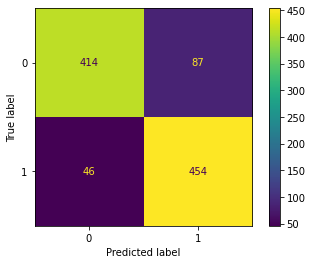

In [21]:
# Construct a confusion matrix to display the results of the hard ensemble classifier
hard_maj_mtx = confusion_matrix(labels_np, hard_maj_np)

# Display and plot the matrix
dis_hard_mtx = ConfusionMatrixDisplay(confusion_matrix=hard_maj_mtx)
dis_hard_mtx.plot()

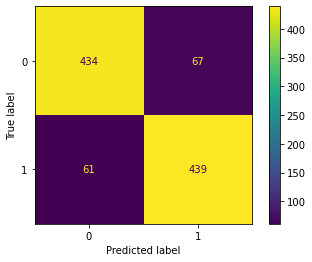

In [22]:
# Construct a confusion matrix to display the results of the soft ensemble classifier
soft_maj_mtx = confusion_matrix(labels_np, soft_maj_np)

# Display and plot the matrix
dis_soft_mtx = ConfusionMatrixDisplay(confusion_matrix=soft_maj_mtx)
dis_soft_mtx.plot()